# Cross-Validation Results Analysis

This notebook collects results from DDH experiments and identifies the best performing models based on validation metrics.


In [211]:
import json
import os
import pandas as pd
import glob
from pathlib import Path
import numpy as np


In [212]:
def collect_results(base_path="../baselines"):
    """
    Simple function to collect all results from JSON files.
    """
    results = []
    
    algorithms = {
        'DDH_results_TC': 'DDH_TC',
        'DDH_results': 'DDH', 
    }
    
    datasets = ['nasa', 'mimic', 'big_rw']
    
    # Find all DDH_results folders
    ddh_folders = []
    for folder in os.listdir(base_path):
        if folder.startswith("DDH_results") and not folder.endswith("_previous"):
            ddh_folders.append(os.path.join(base_path, folder))
    
    print(f"Found DDH results folders: {[os.path.basename(f) for f in ddh_folders]}")
    
    # Collect results
    for ddh_folder in ddh_folders:
        results_pattern = os.path.join(ddh_folder, "**/results.json")
        json_files = glob.glob(results_pattern, recursive=True)
        
        print(f"Processing {len(json_files)} results from {os.path.basename(ddh_folder)}...")
        
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Extract metadata from path
                path_parts = Path(json_file).parts
                
                algorithm = None
                dataset = None
                for part in path_parts:
                    if part in algorithms:
                        algorithm = algorithms[part]
                    elif part in datasets:
                        dataset = part
                
                if algorithm is None or dataset is None:
                    continue
                
                # Extract hyperparameters for DDH_TC
                lambda_val = None
                target_lr_val = None
                
                if algorithm == 'DDH_TC':
                    for part in path_parts:
                        if part.startswith('lambda_'):
                            lambda_val = float(part.replace('lambda_', ''))
                        elif part.startswith('target_lr_'):
                            target_lr_val = float(part.replace('target_lr_', ''))
                
                # Add metadata
                data['algorithm'] = algorithm
                data['dataset'] = dataset
                data['file_path'] = json_file
                if lambda_val is not None:
                    data['lambda_'] = lambda_val
                if target_lr_val is not None:
                    data['target_lr'] = target_lr_val
                
                results.append(data)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
    
    print(f"Successfully collected {len(results)} experiments")
    return results


In [213]:
# Collect all results from JSON files
results = collect_results()
df = pd.DataFrame(results)
print(f"\nTotal experiments: {len(df)}")

if len(df) > 0:
    print(f"Datasets: {df['dataset'].unique()}")
    print(f"Algorithms: {df['algorithm'].unique()}")
    if 'seed' in df.columns:
        print(f"Seeds: {sorted(df['seed'].unique())}")
    
    print("\n=== Dataset and Algorithm Distribution ===")
    print(df.groupby(['dataset', 'algorithm']).size().to_frame('count'))
    
    # Show available hyperparameters
    if 'lambda_' in df.columns:
        print(f"\nLambda values: {sorted(df['lambda_'].unique())}")
    if 'target_lr' in df.columns:
        print(f"Target LR values: {sorted(df['target_lr'].unique())}")
else:
    print("No results found!")


Found DDH results folders: ['DDH_results_TC', 'DDH_results']
Processing 135 results from DDH_results_TC...
Processing 30 results from DDH_results...
Successfully collected 165 experiments

Total experiments: 165
Datasets: ['mimic' 'nasa' 'big_rw']
Algorithms: ['DDH_TC' 'DDH']
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

=== Dataset and Algorithm Distribution ===
                   count
dataset algorithm       
big_rw  DDH           10
mimic   DDH           10
        DDH_TC        55
nasa    DDH           10
        DDH_TC        80

Lambda values: [0.1, 0.5, 0.8, 0.95, nan]
Target LR values: [0.05, 0.1, 0.25, nan]


## Best Validation Performance Analysis


In [214]:
# Simple NASA dataset summary 
def analyze_nasa_summary(df):
    """Simple summary of NASA results."""
    
    # Filter for NASA only
    nasa_df = df[df['dataset'] == 'nasa']
    
    print("NASA Dataset Summary:")
    print(f"Total experiments: {len(nasa_df)}")
    print(f"Algorithms: {nasa_df['algorithm'].unique()}")
    print(f"Seeds: {sorted(nasa_df['seed'].unique())}")
    
    if 'lambda_' in nasa_df.columns:
        lambda_vals = [x for x in nasa_df['lambda_'].unique() if x is not None]
        print(f"Lambda values: {sorted(lambda_vals)}")
    
    if 'target_lr' in nasa_df.columns:
        tau_vals = [x for x in nasa_df['target_lr'].unique() if x is not None] 
        print(f"Target LR (τ) values: {sorted(tau_vals)}")

analyze_nasa_summary(df)


NASA Dataset Summary:
Total experiments: 90
Algorithms: ['DDH_TC' 'DDH']
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Lambda values: [0.1, 0.5, 0.8, 0.95, nan]
Target LR (τ) values: [0.05, 0.1, 0.25, nan]


In [215]:
df

,seed,lambda_,target_lr,test_hazard_loss,test_ranking_loss,test_prediction_loss,test_ci,test_ibs,val_hazard_loss,val_ranking_loss,val_prediction_loss,val_ci,val_ibs,total_history,algorithm,dataset,file_path
0,2,0.50,0.05,0.020068,0.659926,0.133165,0.958333,0.577320,0.023077,0.998967,0.086479,0.642857,0.593725,"[1.750640869140625, 1.6298716068267822, 1.5795...",DDH_TC,mimic,../baselines/DDH_results_TC/mimic/seed_2/lambd...
1,2,0.50,0.10,0.018564,0.644909,0.153285,0.916667,0.550425,0.020576,1.029043,0.097348,0.285714,0.542961,"[1.7505292892456055, 1.626136302947998, 1.5659...",DDH_TC,mimic,../baselines/DDH_results_TC/mimic/seed_2/lambd...
2,2,0.50,0.25,0.014875,0.594731,0.271334,0.916667,0.560962,0.015238,1.211059,0.187121,0.214286,0.502367,"[1.7502093315124512, 1.6152533292770386, 1.524...",DDH_TC,mimic,../baselines/DDH_results_TC/mimic/seed_2/lambd...
3,2,0.95,0.05,0.046025,0.692287,0.219888,0.958333,0.616210,0.076732,0.992120,0.162574,0.571429,0.573531,"[1.776904821395874, 1.6716885566711426, 1.5959...",DDH_TC,mimic,../baselines/DDH_results_TC/mimic/seed_2/lambd...
4,2,0.95,0.10,0.021721,0.577533,0.268750,0.875000,0.579206,0.029382,1.059078,0.191911,0.142857,0.517697,"[1.7768399715423584, 1.6696102619171143, 1.583...",DDH_TC,mimic,../baselines/DDH_results_TC/mimic/seed_2/lambd...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,1,NaN,NaN,0.000579,0.644233,0.497213,0.900826,0.055605,0.002121,0.837740,0.470415,0.825704,0.068694,"[1.7334973812103271, 1.2610747814178467, 1.136...",DDH,nasa,../baselines/DDH_results/nasa/seed_1/results.json
161,8,NaN,NaN,0.001200,0.780417,0.529113,0.840385,0.040091,0.000640,0.767492,0.552070,0.871901,0.053224,"[1.7892504930496216, 1.2838470935821533, 1.136...",DDH,nasa,../baselines/DDH_results/nasa/seed_8/results.json
162,9,NaN,NaN,0.000495,0.632670,0.420886,0.889925,0.044550,0.000338,0.722898,0.445438,0.845992,0.061811,"[1.7724213600158691, 1.2655918598175049, 1.110...",DDH,nasa,../baselines/DDH_results/nasa/seed_9/results.json
163,0,NaN,NaN,0.000443,0.813180,0.522342,0.782051,0.062502,0.000324,0.851848,0.492161,0.703196,0.088429,"[1.8001067638397217, 1.303817629814148, 1.1375...",DDH,nasa,../baselines/DDH_results/nasa/seed_0/results.json


In [216]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 8)


In [217]:
def plot_nasa_test_validation_comparison(df):
    """Plot NASA dataset with test/val metrics, grouped by lambda only."""
    
    # Filter NASA data only
    nasa_df = df[df['dataset'] == 'nasa']
    ddh_data = nasa_df[nasa_df['algorithm'] == 'DDH']
    ddh_tc_data = nasa_df[nasa_df['algorithm'] == 'DDH_TC']
    
    if len(nasa_df) == 0:
        print("No NASA data available")
        return
    
    # Process DDH_TC data
    tc_grouped = None
    if len(ddh_tc_data) > 0:
        tc_grouped = ddh_tc_data.groupby(['lambda_', 'target_lr']).agg({
            'test_ci': ['mean', 'std', 'count'],
            'test_ibs': ['mean', 'std', 'count'],
            'val_ci': ['mean', 'std'],
            'val_ibs': ['mean', 'std']
        }).round(4)
        
        tc_grouped.columns = ['_'.join(col).strip() for col in tc_grouped.columns]
        tc_grouped = tc_grouped.reset_index()
        
        # Find best validation configurations
        best_val_ci_idx = tc_grouped['val_ci_mean'].idxmax()
        best_val_ibs_idx = tc_grouped['val_ibs_mean'].idxmin()
        best_ci_config = tc_grouped.loc[best_val_ci_idx]
        best_ibs_config = tc_grouped.loc[best_val_ibs_idx]
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('NASA Dataset - Test vs Validation Performance', fontsize=16, fontweight='bold')
    
    # Plot 1: C-Index
    ax1.set_title('C-Index: Test (•) vs Validation (■)', fontsize=14, fontweight='bold')
    
    # DDH baseline
    if len(ddh_data) > 0:
        baseline_test_ci = ddh_data['test_ci'].mean()
        baseline_val_ci = ddh_data['val_ci'].mean()
        baseline_test_ci_err = ddh_data['test_ci'].std() / np.sqrt(len(ddh_data))
        baseline_val_ci_err = ddh_data['val_ci'].std() / np.sqrt(len(ddh_data))
        
        ax1.errorbar([-0.1], [baseline_test_ci], yerr=[baseline_test_ci_err],
                    marker='o', markersize=15, color='red', linewidth=2,
                    label='DDH Baseline', capsize=5)
        ax1.errorbar([-0.1], [baseline_val_ci], yerr=[baseline_val_ci_err],
                    marker='s', markersize=15, color='red', linewidth=2,
                    capsize=5, alpha=0.7)
    
    # DDH_TC combinations
    if tc_grouped is not None and len(tc_grouped) > 0:
        target_lrs = sorted(tc_grouped['target_lr'].unique())
        colors = plt.cm.viridis(np.linspace(0, 1, len(target_lrs)))
        lambda_values = sorted(tc_grouped['lambda_'].unique())
        
        # Create x-positions: lambda values equally spaced, target_lr clustered around each
        # Shift lambda positions to right to make room for baseline
        lambda_positions = np.arange(1, len(lambda_values) + 1)
        tau_offsets = np.linspace(-0.15, 0.15, len(target_lrs))
        
        for i, target_lr in enumerate(target_lrs):
            subset = tc_grouped[tc_grouped['target_lr'] == target_lr]
            
            x_vals = []
            y_test = []
            y_val = []  
            err_test = []
            err_val = []
            
            for _, row in subset.iterrows():
                lambda_idx = lambda_values.index(row['lambda_'])
                x_vals.append(lambda_positions[lambda_idx] + tau_offsets[i])
                y_test.append(row['test_ci_mean'])
                y_val.append(row['val_ci_mean'])
                err_test.append(row['test_ci_std'] / np.sqrt(row['test_ci_count']))
                err_val.append(row['val_ci_std'] / np.sqrt(row['test_ci_count']))
            
            # Add legend only for target_lr color coding
            ax1.errorbar(x_vals, y_test, yerr=err_test,
                        marker='o', markersize=12, color=colors[i], linewidth=2,
                        label=f'τ={target_lr}', capsize=3, alpha=0.9, linestyle='none')
            
            ax1.errorbar(x_vals, y_val, yerr=err_val, linewidth=2,
                        marker='s', markersize=12, color=colors[i],
                        capsize=3, alpha=0.5, linestyle='none')
        
        ax1.set_xticks(lambda_positions)
        ax1.set_xticklabels([f'λ={lam}' for lam in lambda_values])
        ax1.set_xlim(-0.2, len(lambda_values) + 0.8)
        
        # Highlight best validation CI configuration
        best_lambda = best_ci_config['lambda_']
        best_tau = best_ci_config['target_lr']
        best_test_ci = best_ci_config['test_ci_mean']
        lambda_idx = lambda_values.index(best_lambda)
        tau_idx = target_lrs.index(best_tau)
        best_x = lambda_positions[lambda_idx] + tau_offsets[tau_idx]
        
        ax1.scatter([best_x], [best_test_ci], s=500, marker='*', color='gold', 
                   edgecolor='black', linewidth=3, zorder=10)
    
    ax1.set_xlabel('Lambda', fontsize=12, fontweight='bold')
    ax1.set_ylabel('C-Index', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: IBS
    ax2.set_title('IBS: Test (•) vs Validation (■) - Lower is Better', fontsize=14, fontweight='bold')
    
    # DDH baseline
    if len(ddh_data) > 0:
        baseline_test_ibs = ddh_data['test_ibs'].mean()
        baseline_val_ibs = ddh_data['val_ibs'].mean()
        baseline_test_ibs_err = ddh_data['test_ibs'].std() / np.sqrt(len(ddh_data))
        baseline_val_ibs_err = ddh_data['val_ibs'].std() / np.sqrt(len(ddh_data))
        
        ax2.errorbar([-0.1], [baseline_test_ibs], yerr=[baseline_test_ibs_err],
                    marker='o', markersize=12, color='red', linewidth=2, capsize=5)
        ax2.errorbar([-0.1], [baseline_val_ibs], yerr=[baseline_val_ibs_err],
                    marker='s', markersize=12, color='red', linewidth=2, capsize=5, alpha=0.7)
    
    # DDH_TC combinations
    if tc_grouped is not None and len(tc_grouped) > 0:
        for i, target_lr in enumerate(target_lrs):
            subset = tc_grouped[tc_grouped['target_lr'] == target_lr]
            
            x_vals = []
            y_test = []
            y_val = []
            err_test = []
            err_val = []
            
            for _, row in subset.iterrows():
                lambda_idx = lambda_values.index(row['lambda_'])
                x_vals.append(lambda_positions[lambda_idx] + tau_offsets[i])
                y_test.append(row['test_ibs_mean'])
                y_val.append(row['val_ibs_mean'])
                err_test.append(row['test_ibs_std'] / np.sqrt(row['test_ibs_count']))
                err_val.append(row['val_ibs_std'] / np.sqrt(row['test_ibs_count']))
            
            ax2.errorbar(x_vals, y_test, yerr=err_test,
                        marker='o', markersize=12, color=colors[i], linewidth=2,
                        capsize=3, alpha=0.9, linestyle='none')
            
            ax2.errorbar(x_vals, y_val, yerr=err_val, linewidth=2,
                        marker='s', markersize=12, color=colors[i],
                        capsize=3, alpha=0.5, linestyle='none')
        
        ax2.set_xticks(lambda_positions)
        ax2.set_xticklabels([f'λ={lam}' for lam in lambda_values])
        ax2.set_xlim(-0.2, len(lambda_values) + 0.8)
        
        # Highlight best validation IBS configuration
        best_lambda_ibs = best_ibs_config['lambda_']
        best_tau_ibs = best_ibs_config['target_lr']
        best_test_ibs = best_ibs_config['test_ibs_mean']
        lambda_idx_ibs = lambda_values.index(best_lambda_ibs)
        tau_idx_ibs = target_lrs.index(best_tau_ibs)
        best_x_ibs = lambda_positions[lambda_idx_ibs] + tau_offsets[tau_idx_ibs]
        
        ax2.scatter([best_x_ibs], [best_test_ibs], s=500, marker='*', color='gold',
                   edgecolor='black', linewidth=3, zorder=10)
    
    ax2.set_xlabel('Lambda', fontsize=12, fontweight='bold')
    ax2.set_ylabel('IBS', fontsize=12, fontweight='bold')
    # ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Create shared legend below subplots
    legend_elements = []
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='red', linestyle='None', 
                                    markersize=12, label='DDH Baseline'))
    
    if tc_grouped is not None and len(tc_grouped) > 0:
        for i, target_lr in enumerate(target_lrs):
            legend_elements.append(plt.Line2D([0], [0], marker='o', color=colors[i], linestyle='None',
                                            markersize=10, label=f'τ={target_lr}'))
        
        legend_elements.append(plt.Line2D([0], [0], marker='*', color='gold', linestyle='None',
                                        markersize=16, markeredgecolor='black', label='Best Val→Test'))
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
              ncol=len(legend_elements), frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for legend
    plt.show()
    
    # Print best configurations
    if tc_grouped is not None and len(tc_grouped) > 0:
        print(f"Best Val CI config: λ={best_ci_config['lambda_']}, τ={best_ci_config['target_lr']} → Test CI: {best_ci_config['test_ci_mean']:.4f}")
        print(f"Best Val IBS config: λ={best_ibs_config['lambda_']}, τ={best_ibs_config['target_lr']} → Test IBS: {best_ibs_config['test_ibs_mean']:.4f}")
    
    return ['nasa']


Creating NASA test vs validation comparison plot...


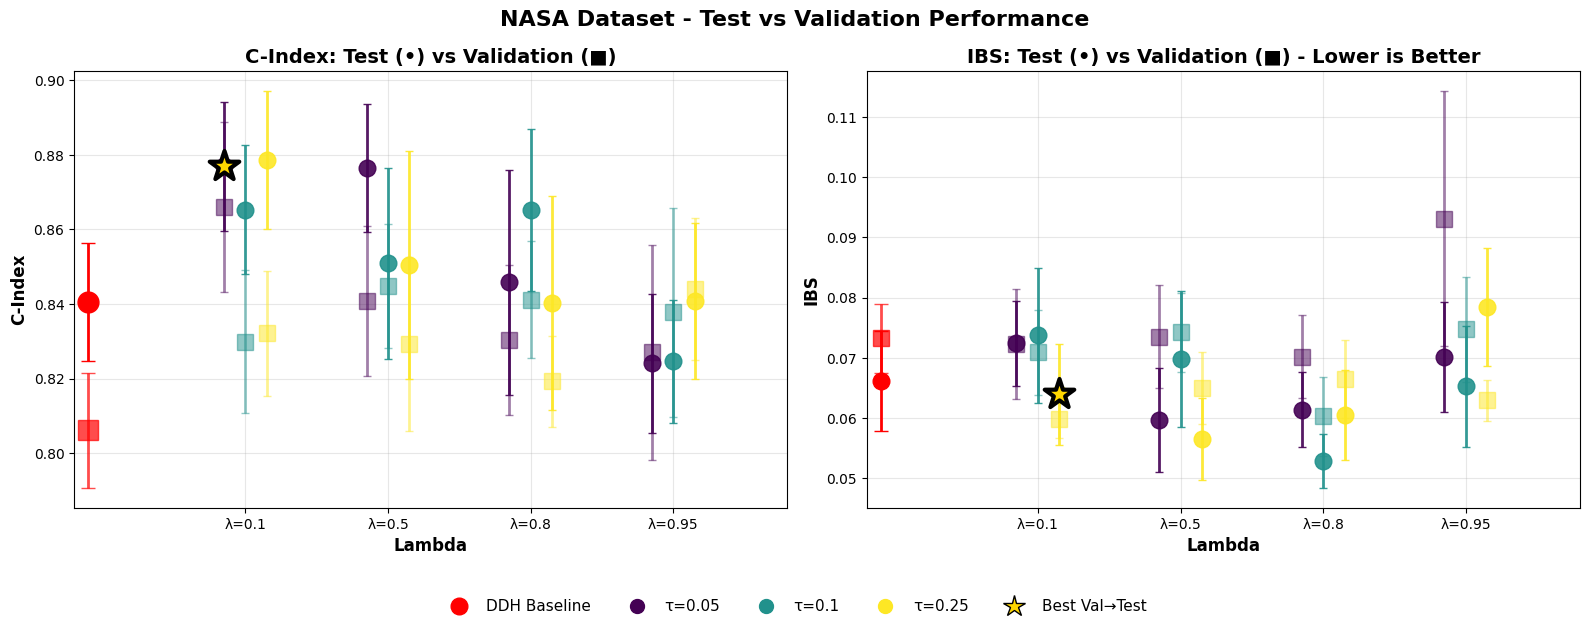

Best Val CI config: λ=0.1, τ=0.05 → Test CI: 0.8770
Best Val IBS config: λ=0.1, τ=0.25 → Test IBS: 0.0639

Generated NASA-specific plot


In [218]:
# Create NASA test vs validation comparison plot
if len(df) > 0:
    print("Creating NASA test vs validation comparison plot...")
    datasets = plot_nasa_test_validation_comparison(df)
    print(f"\nGenerated NASA-specific plot")
else:
    print("No data available for plotting")


In [202]:
# NASA-only performance table
def create_nasa_performance_table(df):
    """Create a detailed performance table for NASA dataset with best validation configs highlighted."""
    
    print("=" * 130)
    print("NASA DATASET - PERFORMANCE TABLE")
    print("=" * 130)
    
    # Filter for NASA only
    nasa_df = df[df['dataset'] == 'nasa']
    
    # DDH Baseline for NASA
    ddh_data = nasa_df[nasa_df['algorithm'] == 'DDH']
    if len(ddh_data) > 0:
        baseline_test_ci = ddh_data['test_ci'].mean()
        baseline_val_ci = ddh_data['val_ci'].mean()
        baseline_test_ibs = ddh_data['test_ibs'].mean()
        baseline_val_ibs = ddh_data['val_ibs'].mean()
        baseline_test_ci_std = ddh_data['test_ci'].std()
        baseline_val_ci_std = ddh_data['val_ci'].std()
        baseline_test_ibs_std = ddh_data['test_ibs'].std()
        baseline_val_ibs_std = ddh_data['val_ibs'].std()
        
        print(f"\n{'DDH BASELINE':<20} {'Test CI':<15} {'Val CI':<15} {'Test IBS':<15} {'Val IBS':<15} {'Seeds':<10}")
        print("-" * 100)
        test_ci_str = f"{baseline_test_ci:.4f}±{baseline_test_ci_std:.4f}"
        val_ci_str = f"{baseline_val_ci:.4f}±{baseline_val_ci_std:.4f}"
        test_ibs_str = f"{baseline_test_ibs:.4f}±{baseline_test_ibs_std:.4f}"
        val_ibs_str = f"{baseline_val_ibs:.4f}±{baseline_val_ibs_std:.4f}"
        print(f"{'Average ± Std':<20} {test_ci_str:<15} {val_ci_str:<15} {test_ibs_str:<15} {val_ibs_str:<15} {len(ddh_data):<10}")
    
    # DDH_TC combinations for NASA
    ddh_tc_data = nasa_df[nasa_df['algorithm'] == 'DDH_TC']
    if len(ddh_tc_data) > 0:
        tc_grouped = ddh_tc_data.groupby(['lambda_', 'target_lr']).agg({
            'test_ci': ['mean', 'std', 'count'],
            'test_ibs': ['mean', 'std'],
            'val_ci': ['mean', 'std'],
            'val_ibs': ['mean', 'std']
        }).round(4)
        
        tc_grouped.columns = ['_'.join(col).strip() for col in tc_grouped.columns]
        tc_grouped = tc_grouped.reset_index()
        
        # Find best validation configurations
        best_val_ci_idx = tc_grouped['val_ci_mean'].idxmax()
        best_val_ibs_idx = tc_grouped['val_ibs_mean'].idxmin()
        best_ci_config = tc_grouped.loc[best_val_ci_idx]
        best_ibs_config = tc_grouped.loc[best_val_ibs_idx]
        
        print(f"\n{'DDH_TC COMBINATIONS':<20} {'Test CI':<15} {'Val CI':<15} {'Test IBS':<15} {'Val IBS':<15} {'Seeds':<10}")
        print("-" * 110)
        
        for idx, row in tc_grouped.iterrows():
            lambda_val = row['lambda_']
            target_lr = row['target_lr']
            test_ci = f"{row['test_ci_mean']:.4f}±{row['test_ci_std']:.4f}"
            val_ci = f"{row['val_ci_mean']:.4f}±{row['val_ci_std']:.4f}"
            test_ibs = f"{row['test_ibs_mean']:.4f}±{row['test_ibs_std']:.4f}"
            val_ibs = f"{row['val_ibs_mean']:.4f}±{row['val_ibs_std']:.4f}"
            n_seeds = int(row['test_ci_count'])
            
            config_name = f"λ={lambda_val}, τ={target_lr}"
            
            # Add markers for best configs
            marker = ""
            if idx == best_val_ci_idx:
                marker += " ★ BEST VAL CI"
            if idx == best_val_ibs_idx:
                marker += " ★ BEST VAL IBS"
            
            print(f"{config_name:<20} {test_ci:<15} {val_ci:<15} {test_ibs:<15} {val_ibs:<15} {n_seeds:<10}{marker}")
        
        print("\n" + "="*130)
        print("BEST VALIDATION CONFIGURATIONS:")
        print("="*130)
        print(f"★ BEST VAL CI:  λ={best_ci_config['lambda_']}, τ={best_ci_config['target_lr']} → Val CI: {best_ci_config['val_ci_mean']:.4f} → Test CI: {best_ci_config['test_ci_mean']:.4f}")
        print(f"★ BEST VAL IBS: λ={best_ibs_config['lambda_']}, τ={best_ibs_config['target_lr']} → Val IBS: {best_ibs_config['val_ibs_mean']:.4f} → Test IBS: {best_ibs_config['test_ibs_mean']:.4f}")

create_nasa_performance_table(df)


NASA DATASET - PERFORMANCE TABLE

DDH BASELINE         Test CI         Val CI          Test IBS        Val IBS         Seeds     
----------------------------------------------------------------------------------------------------
Average ± Std        0.8406±0.0504   0.8061±0.0488   0.0661±0.0263   0.0732±0.0180   10        

DDH_TC COMBINATIONS  Test CI         Val CI          Test IBS        Val IBS         Seeds     
--------------------------------------------------------------------------------------------------------------
λ=0.1, τ=0.05        0.8770±0.0457   0.8660±0.0605   0.0724±0.0186   0.0723±0.0243   7          ★ BEST VAL CI
λ=0.1, τ=0.1         0.8647±0.0502   0.8290±0.0553   0.0674±0.0266   0.0682±0.0188   6         
λ=0.1, τ=0.25        0.8791±0.0536   0.8326±0.0486   0.0585±0.0186   0.0606±0.0091   6          ★ BEST VAL IBS
λ=0.5, τ=0.05        0.8769±0.0496   0.8473±0.0555   0.0622±0.0240   0.0725±0.0247   6         
λ=0.5, τ=0.1         0.8468±0.0731   0.8435±0.0478  

In [189]:
# NASA dataset analysis is already shown above in analyze_nasa_summary()
print("NASA dataset analysis complete!")


NASA dataset analysis complete!
